# Comparison of the Best Stage-2 Hyperparameter-Tuning Runs

This notebook compares the best Stage-2 candidate from each selected tuning experiment.
Stage-1 convergence and the Stage-1 result of the winning Stage-2 configuration remain
visible, while Stage-2 replication data are used for the final KPI comparison.

All uncertainty bars show **95% t-confidence intervals**. Lower objective values and
higher total rewards are better.

In [13]:
from pathlib import Path
import json
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    pass

sns.set_context("notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 100)

## Configuration

Add or remove folder names in `SELECTED_RUNS`. The number of compared experiments is
derived automatically. Optional labels and colors can be supplied without changing the
loading or plotting code.

In [14]:
TUNING_RESULTS_ROOT = Path("results/rl_tuning_results")

SELECTED_RUNS = [
    "rl_tuning_hpc_100",
    # # "rl_tuning_hpc_60",
    "rl_tuning_hpc_fixed120",
    "rl_tuning_hpc_fixed758",
    "rl_tuning_hpc_gamma_high",
    "rl_tuning_hpc_gamma_low",
]

# Optional overrides. Missing entries fall back to a readable folder-name label.
RUN_LABELS = {
    # "rl_tuning_hpc_fixed758": "Fixed risk window 758",
}
RUN_COLORS = {
    # "rl_tuning_hpc_fixed758": "tab:blue",
}

KPI_METRICS = [
    "total_reward",
    "late_order_fraction",
    "n_orders_late",
    "time_in_system_mean",
    "wip_mean",
    "n_orders_completed",
]

CONFIDENCE_LEVEL = 0.95

## Loading and Statistical Helpers

In [15]:
def warn(message: str) -> None:
    warnings.warn(message, stacklevel=2)
    print(f"WARNING: {message}")


def readable_run_label(run_name: str) -> str:
    label = run_name.removeprefix("rl_tuning_").replace("_", " ")
    return label.upper() if label.startswith("hpc ") else label.title()


def read_json(path: Path) -> dict:
    if not path.exists():
        warn(f"Missing JSON: {path}")
        return {}
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception as exc:
        warn(f"Could not read {path}: {exc}")
        return {}


def read_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        warn(f"Missing CSV: {path}")
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except Exception as exc:
        warn(f"Could not read {path}: {exc}")
        return pd.DataFrame()


def valid_rows(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    result = df.copy()
    if "error" in result:
        result = result[result["error"].fillna("").astype(str).str.strip().eq("")]
    return result


def numeric(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    result = df.copy()
    for column in columns:
        if column in result:
            result[column] = pd.to_numeric(result[column], errors="coerce")
    return result


def mean_ci(values, confidence: float = CONFIDENCE_LEVEL) -> tuple[float, float, int]:
    clean = pd.to_numeric(pd.Series(values), errors="coerce").dropna().to_numpy(float)
    n = len(clean)
    if n == 0:
        return np.nan, np.nan, 0
    mean = float(np.mean(clean))
    if n < 2:
        return mean, np.nan, n
    sem = stats.sem(clean)
    half_width = float(stats.t.ppf((1 + confidence) / 2, df=n - 1) * sem)
    return mean, half_width, n


def ci_from_summary(mean, std, n, confidence: float = CONFIDENCE_LEVEL) -> float:
    if pd.isna(mean) or pd.isna(std) or pd.isna(n) or int(n) < 2:
        return np.nan
    return float(stats.t.ppf((1 + confidence) / 2, df=int(n) - 1) * float(std) / np.sqrt(int(n)))


def empty_plot(ax, message: str) -> None:
    ax.text(0.5, 0.5, message, ha="center", va="center", transform=ax.transAxes)
    ax.set_axis_off()


def local_candidate_dir(run_dir: Path, best: dict) -> Path | None:
    try:
        expected = run_dir / "stage2" / (
            f"candidate_rank_{int(best['candidate_rank']):02d}_"
            f"trial_{int(best['source_trial_index']):03d}"
        )
        if expected.exists():
            return expected
    except (KeyError, TypeError, ValueError):
        pass

    raw = best.get("candidate_dir")
    if raw:
        fallback = run_dir / "stage2" / Path(str(raw)).name
        if fallback.exists():
            return fallback
    return None


def load_experiment(run_name: str) -> dict:
    run_dir = TUNING_RESULTS_ROOT / run_name
    label = RUN_LABELS.get(run_name, readable_run_label(run_name))
    stage1 = read_csv(run_dir / "stage1" / "stage1_trials.csv")
    stage1_config = read_json(run_dir / "stage1" / "stage1_config.json")
    best_document = read_json(run_dir / "stage2" / "stage2_best_candidate.json")
    best = best_document.get("best_candidate", {})

    # Fallback if the dedicated best-candidate JSON is unavailable.
    if not best:
        candidates = read_csv(run_dir / "stage2" / "stage2_candidates.csv")
        if not candidates.empty and "objective_mean" in candidates:
            candidates["objective_mean"] = pd.to_numeric(candidates["objective_mean"], errors="coerce")
            valid_candidates = candidates.dropna(subset=["objective_mean"])
            if not valid_candidates.empty:
                best = valid_candidates.sort_values("objective_mean").iloc[0].to_dict()
                warn(f"{run_name}: selected best Stage-2 row from stage2_candidates.csv.")

    stage1 = numeric(
        stage1,
        [
            "trial_index", "objective_mean", "objective_std", "best_objective_so_far",
            "total_reward_mean", "total_reward_std", "late_order_fraction_mean",
            "n_valid_replications", "alpha", "gamma", "target_final_epsilon",
            "epsilon_decay", "epsilon_min", "risk_t1", "risk_window",
        ],
    )
    if not stage1.empty and "trial_index" in stage1:
        stage1 = stage1.sort_values("trial_index").reset_index(drop=True)
    if (
        not stage1.empty
        and "objective_mean" in stage1
        and ("best_objective_so_far" not in stage1 or stage1["best_objective_so_far"].isna().all())
    ):
        stage1["best_objective_so_far"] = stage1["objective_mean"].cummin()

    source_trial = pd.DataFrame()
    if not stage1.empty and best.get("source_trial_index") is not None and "trial_index" in stage1:
        source_trial = stage1[
            stage1["trial_index"].eq(float(best["source_trial_index"]))
        ].copy()
        if source_trial.empty:
            warn(f"{run_name}: Stage-1 source trial {best['source_trial_index']} was not found.")

    candidate_dir = local_candidate_dir(run_dir, best)
    evaluations = read_csv(candidate_dir / "evaluation.csv") if candidate_dir else pd.DataFrame()
    evaluations = valid_rows(evaluations)
    evaluations = numeric(
        evaluations,
        [
            "replication", "eval_seed", "total_reward", "late_order_fraction",
            "n_orders_late", "time_in_system_mean", "time_in_system_std",
            "time_in_system_max", "wip_mean", "wip_max", "n_orders_completed",
            "n_orders_created", "n_orders_in_date", "n_decision_points",
            "action_0_count", "action_1_count", "action_2_count", "action_3_count",
            "q_table_size",
        ],
    )
    if not evaluations.empty:
        evaluations["run_name"] = run_name
        evaluations["run_label"] = label

    parameter_names = list(
        stage1_config.get("all_parameter_bounds", stage1_config.get("parameter_bounds", {})).keys()
    )
    for name in ["epsilon_decay", "epsilon_min"]:
        if name in best and name not in parameter_names:
            parameter_names.append(name)

    return {
        "run_name": run_name,
        "run_label": label,
        "run_dir": run_dir,
        "stage1": stage1,
        "stage1_config": stage1_config,
        "best": best,
        "source_trial": source_trial,
        "candidate_dir": candidate_dir,
        "evaluations": evaluations,
        "parameter_names": parameter_names,
    }

## Load and Validate Selected Experiments

In [16]:
if len(SELECTED_RUNS) < 1:
    raise ValueError("SELECTED_RUNS must contain at least one experiment folder.")
if len(SELECTED_RUNS) != len(set(SELECTED_RUNS)):
    raise ValueError("SELECTED_RUNS contains duplicate folder names.")

experiments = [load_experiment(run_name) for run_name in SELECTED_RUNS]

validation_rows = []
for exp in experiments:
    validation_rows.append({
        "Run": exp["run_label"],
        "Folder": exp["run_name"],
        "Stage-1 trials": len(exp["stage1"]),
        "Best Stage-2 rank": exp["best"].get("candidate_rank"),
        "Source Stage-1 trial": exp["best"].get("source_trial_index"),
        "Stage-2 replications": len(exp["evaluations"]),
        "Candidate data found": exp["candidate_dir"] is not None,
    })

validation_table = pd.DataFrame(validation_rows)
display(validation_table)

usable_experiments = [
    exp for exp in experiments
    if not exp["stage1"].empty and exp["best"] and not exp["evaluations"].empty
]
if not usable_experiments:
    raise RuntimeError("None of the selected experiments has complete comparison data.")
if len(usable_experiments) != len(experiments):
    warn(
        f"{len(experiments) - len(usable_experiments)} selected experiment(s) are incomplete; "
        "available sections will still be plotted."
    )

palette = {
    exp["run_label"]: RUN_COLORS.get(exp["run_name"], sns.color_palette("tab10", len(experiments))[i])
    for i, exp in enumerate(experiments)
}

,Run,Folder,Stage-1 trials,Best Stage-2 rank,Source Stage-1 trial,Stage-2 replications,Candidate data found
0,HPC 100,rl_tuning_hpc_100,100,2,51,30,True
1,HPC FIXED120,rl_tuning_hpc_fixed120,99,10,18,30,True
2,HPC FIXED758,rl_tuning_hpc_fixed758,100,9,98,30,True
3,HPC GAMMA HIGH,rl_tuning_hpc_gamma_high,100,1,20,30,True
4,HPC GAMMA LOW,rl_tuning_hpc_gamma_low,100,7,55,30,True


## Stage-1 Bayesian-Optimization Convergence

Each line uses the experiment's actual trial indices. Runs with fewer completed trials
therefore end earlier and are not padded or extrapolated.

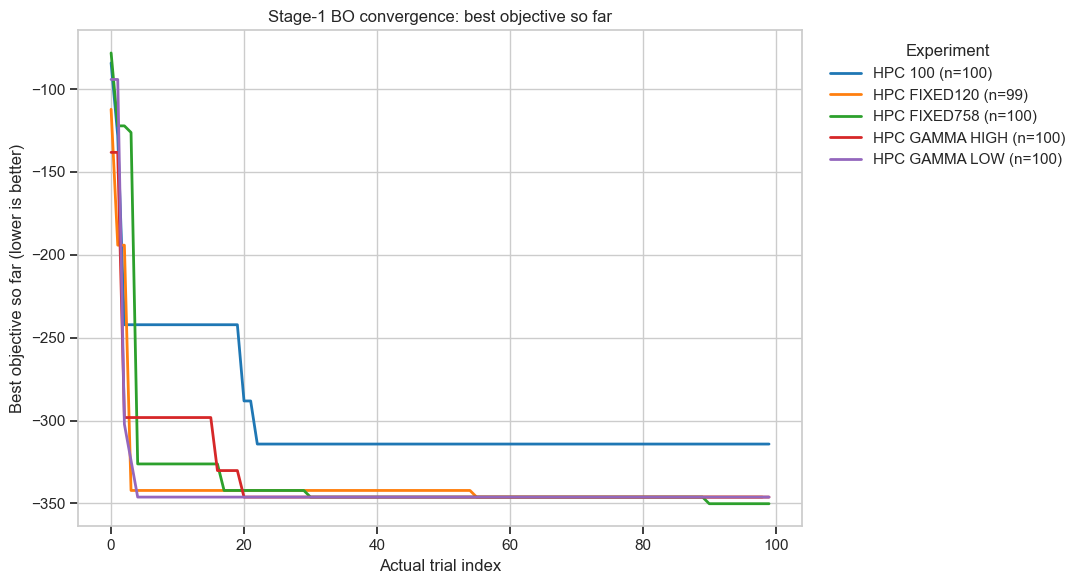

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))
plotted = False
for exp in experiments:
    data = exp["stage1"]
    required = {"trial_index", "best_objective_so_far"}
    if data.empty or not required.issubset(data.columns):
        warn(f"{exp['run_name']}: no Stage-1 convergence series available.")
        continue
    clean = data.dropna(subset=list(required))
    if clean.empty:
        continue
    ax.plot(
        clean["trial_index"],
        clean["best_objective_so_far"],
        linewidth=2,
        label=f"{exp['run_label']} (n={len(clean)})",
        color=palette[exp["run_label"]],
    )
    plotted = True

if plotted:
    ax.set_title("Stage-1 BO convergence: best objective so far")
    ax.set_xlabel("Actual trial index")
    ax.set_ylabel("Best objective so far (lower is better)")
    ax.legend(title="Experiment", bbox_to_anchor=(1.02, 1), loc="upper left")
else:
    empty_plot(ax, "No Stage-1 convergence data available.")
plt.tight_layout()
plt.show()

## Stage-1 Objective of Each Stage-2 Winner

For every experiment, this selects the Stage-1 trial whose parameter combination later
produced that experiment's best Stage-2 result. Error bars are 95% t-confidence intervals.

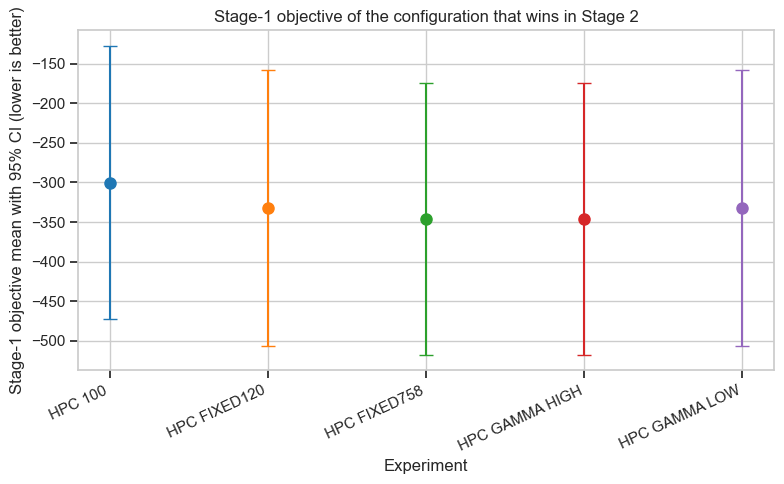

In [18]:
stage1_winner_rows = []
for exp in experiments:
    if exp["source_trial"].empty:
        continue
    row = exp["source_trial"].iloc[0]
    mean = row.get("objective_mean", np.nan)
    std = row.get("objective_std", np.nan)
    n = row.get("n_valid_replications", np.nan)
    stage1_winner_rows.append({
        "run_name": exp["run_name"],
        "run_label": exp["run_label"],
        "source_trial_index": int(row["trial_index"]),
        "objective_mean": mean,
        "objective_ci95": ci_from_summary(mean, std, n),
        "n": n,
    })

stage1_winners = pd.DataFrame(stage1_winner_rows)
fig, ax = plt.subplots(figsize=(max(8, 1.45 * len(stage1_winners)), 5))
if stage1_winners.empty:
    empty_plot(ax, "No Stage-1 winner data available.")
else:
    x = np.arange(len(stage1_winners))
    for index, item in stage1_winners.reset_index(drop=True).iterrows():
        ax.errorbar(
            index,
            item["objective_mean"],
            yerr=item["objective_ci95"],
            fmt="o",
            markersize=8,
            capsize=5,
            color=palette[item["run_label"]],
            ecolor=palette[item["run_label"]],
            zorder=3,
        )
    ax.set_xticks(x, stage1_winners["run_label"], rotation=25, ha="right")
    ax.set_title("Stage-1 objective of the configuration that wins in Stage 2")
    ax.set_ylabel("Stage-1 objective mean with 95% CI (lower is better)")
    ax.set_xlabel("Experiment")
plt.tight_layout()
plt.show()

## Stage-1 vs. Stage-2 Reward

Experiments are sorted by the Stage-2 mean reward from best to worst. Both stages show
95% t-confidence intervals despite their different replication counts.

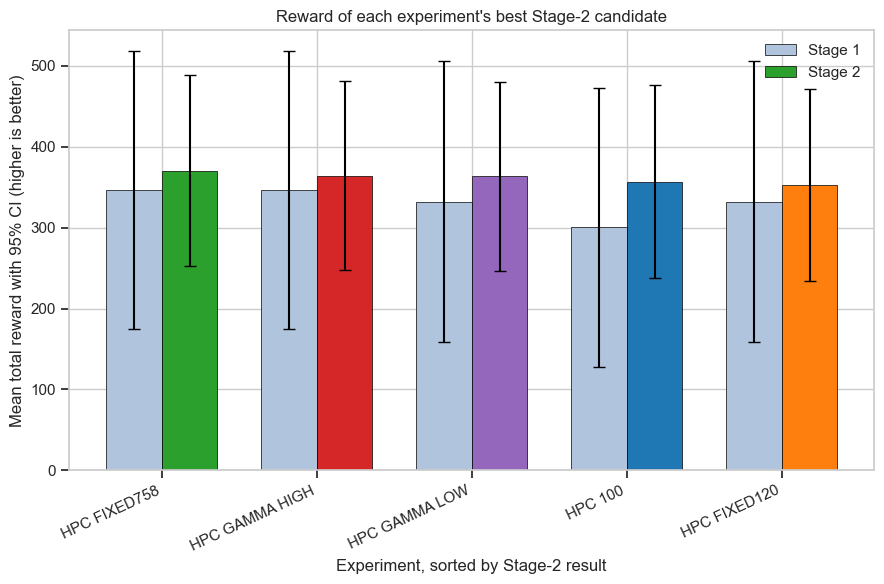

In [19]:
reward_rows = []
for exp in experiments:
    if exp["source_trial"].empty:
        continue
    source = exp["source_trial"].iloc[0]
    best = exp["best"]
    s1_mean = source.get("total_reward_mean", np.nan)
    s1_std = source.get("total_reward_std", np.nan)
    s1_n = source.get("n_valid_replications", np.nan)
    s2_mean = best.get("total_reward_mean", np.nan)
    s2_std = best.get("total_reward_std", np.nan)
    s2_n = best.get("n_valid_replications", len(exp["evaluations"]))

    # Prefer raw Stage-2 replications when available.
    if "total_reward" in exp["evaluations"]:
        raw_mean, raw_ci, raw_n = mean_ci(exp["evaluations"]["total_reward"])
        if raw_n:
            s2_mean, s2_n = raw_mean, raw_n
            s2_ci = raw_ci
        else:
            s2_ci = ci_from_summary(s2_mean, s2_std, s2_n)
    else:
        s2_ci = ci_from_summary(s2_mean, s2_std, s2_n)

    reward_rows.append({
        "run_name": exp["run_name"],
        "run_label": exp["run_label"],
        "stage1_reward_mean": s1_mean,
        "stage1_reward_ci95": ci_from_summary(s1_mean, s1_std, s1_n),
        "stage1_n": s1_n,
        "stage2_reward_mean": s2_mean,
        "stage2_reward_ci95": s2_ci,
        "stage2_n": s2_n,
        "reward_delta": s2_mean - s1_mean,
    })

reward_comparison = (
    pd.DataFrame(reward_rows)
    .sort_values("stage2_reward_mean", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(max(9, 1.55 * len(reward_comparison)), 6))
if reward_comparison.empty:
    empty_plot(ax, "No Stage-1/Stage-2 reward comparison available.")
else:
    x = np.arange(len(reward_comparison))
    width = 0.36
    ax.bar(
        x - width / 2,
        reward_comparison["stage1_reward_mean"],
        width,
        yerr=reward_comparison["stage1_reward_ci95"],
        capsize=4,
        label="Stage 1",
        color="lightsteelblue",
        edgecolor="black",
        linewidth=0.5,
    )
    ax.bar(
        x + width / 2,
        reward_comparison["stage2_reward_mean"],
        width,
        yerr=reward_comparison["stage2_reward_ci95"],
        capsize=4,
        label="Stage 2",
        color=[palette[label] for label in reward_comparison["run_label"]],
        edgecolor="black",
        linewidth=0.5,
    )
    ax.set_xticks(x, reward_comparison["run_label"], rotation=25, ha="right")
    ax.set_title("Reward of each experiment's best Stage-2 candidate")
    ax.set_ylabel("Mean total reward with 95% CI (higher is better)")
    ax.set_xlabel("Experiment, sorted by Stage-2 result")
    ax.legend()
plt.tight_layout()
plt.show()

## Stage-2 KPI Distributions of the Best Candidates

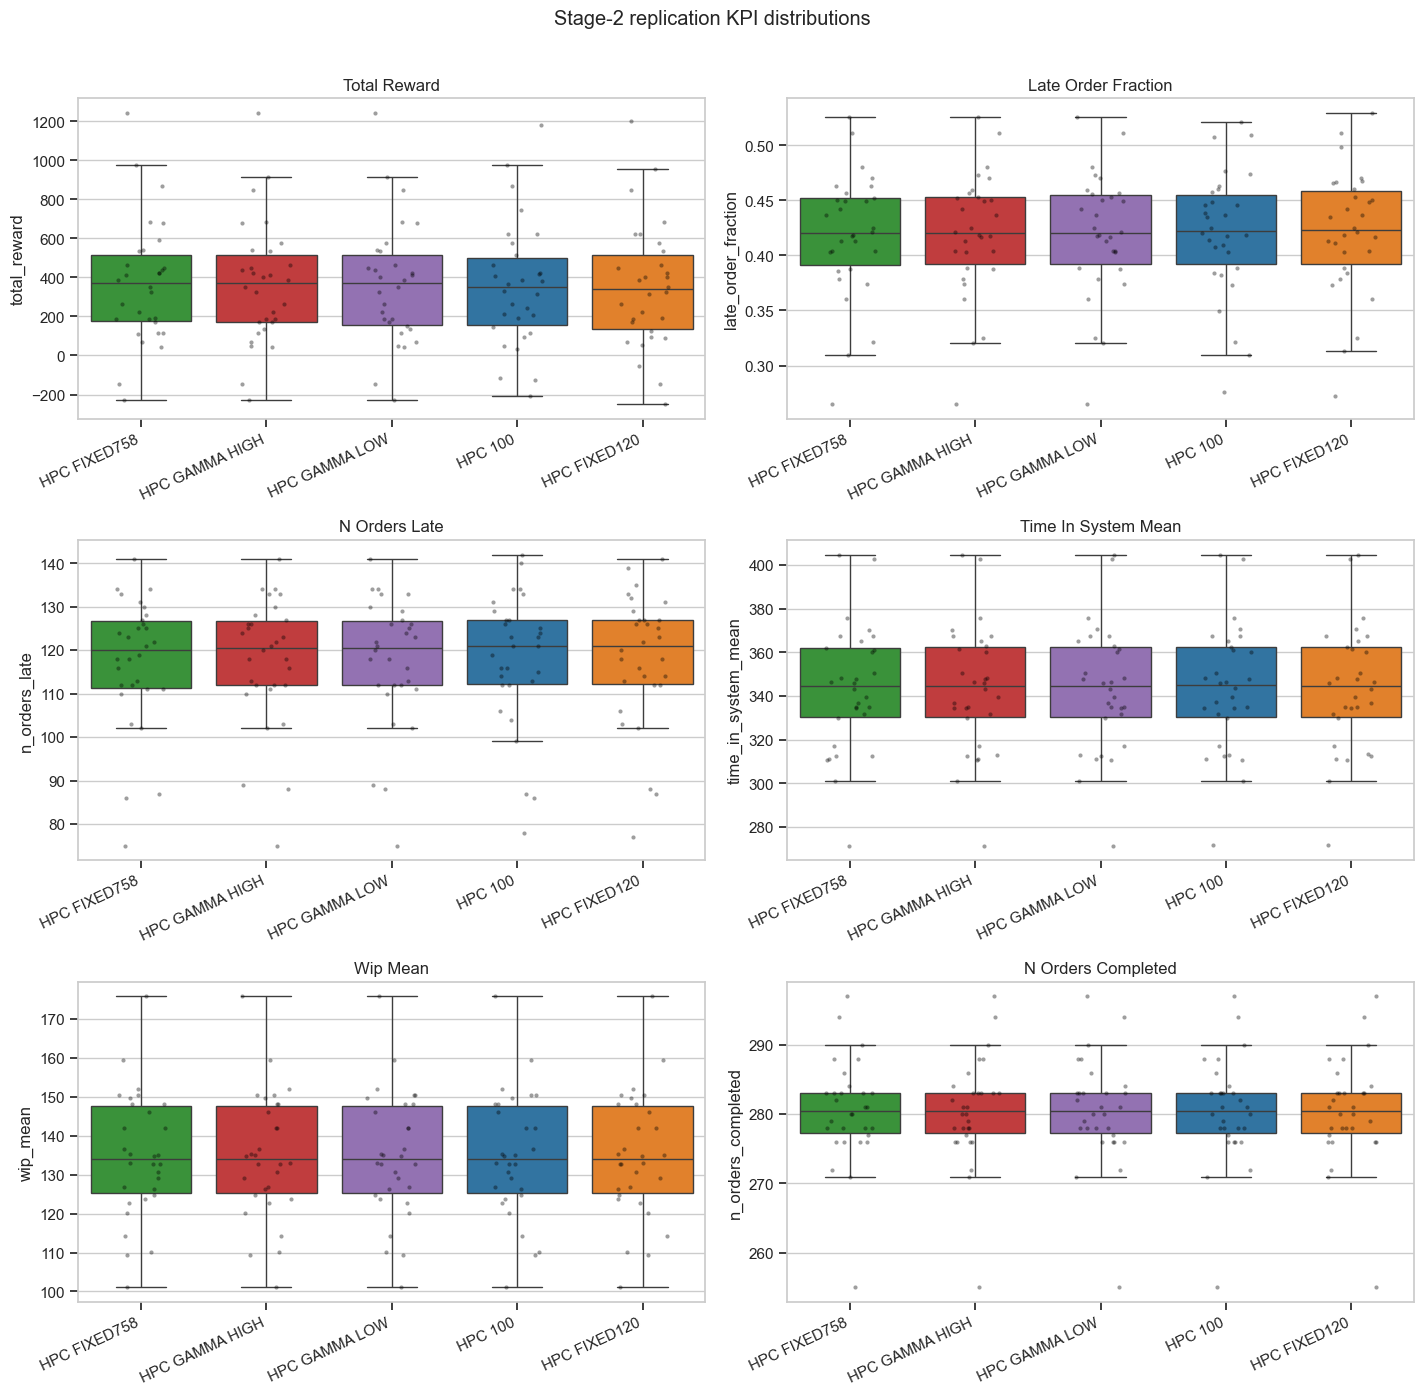

In [20]:
evaluation_frames = [
    exp["evaluations"] for exp in experiments if not exp["evaluations"].empty
]
all_evaluations = (
    pd.concat(evaluation_frames, ignore_index=True, sort=False)
    if evaluation_frames else pd.DataFrame()
)
plot_metrics = [metric for metric in KPI_METRICS if metric in all_evaluations.columns]
run_order = reward_comparison["run_label"].tolist()

if all_evaluations.empty or not plot_metrics:
    fig, ax = plt.subplots(figsize=(8, 4))
    empty_plot(ax, "No Stage-2 KPI replication data available.")
    plt.show()
else:
    n_cols = 2 if len(plot_metrics) > 1 else 1
    n_rows = math.ceil(len(plot_metrics) / n_cols)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(7.2 * n_cols, max(4.8, 4.6 * n_rows)),
        squeeze=False,
    )
    for ax, metric in zip(axes.ravel(), plot_metrics):
        sns.boxplot(
            data=all_evaluations,
            x="run_label",
            y=metric,
            order=run_order,
            hue="run_label",
            palette=palette,
            legend=False,
            showfliers=False,
            ax=ax,
        )
        sns.stripplot(
            data=all_evaluations,
            x="run_label",
            y=metric,
            order=run_order,
            color="black",
            alpha=0.38,
            size=3,
            jitter=0.2,
            ax=ax,
        )
        ax.set_title(metric.replace("_", " ").title())
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=25)
        for tick in ax.get_xticklabels():
            tick.set_ha("right")
    for ax in axes.ravel()[len(plot_metrics):]:
        ax.set_axis_off()
    fig.suptitle("Stage-2 replication KPI distributions", y=1.01)
    plt.tight_layout()
    plt.show()

## Paired Stage-2 Reward Differences

When experiments share evaluation seeds, their rewards can be compared replication by
replication. The best mean-reward experiment is used as the reference. Negative values
indicate that the comparison run achieved a lower reward than the reference on the same seed.

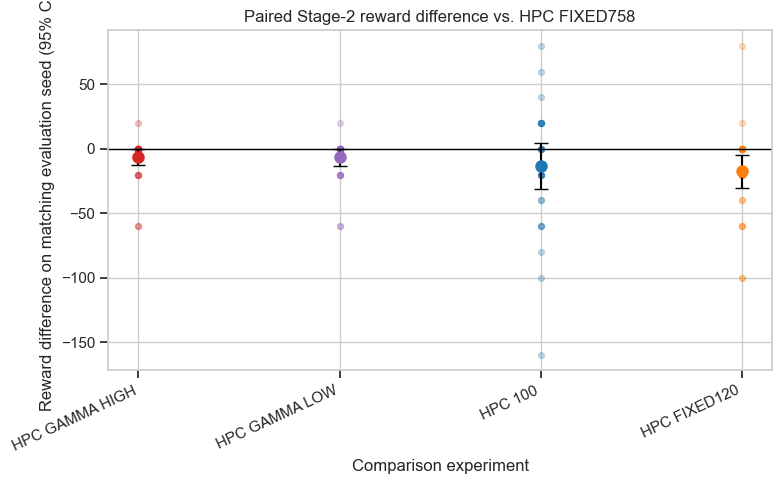

,run_label,reference,paired_mean_difference,paired_ci95,n_pairs
0,HPC GAMMA HIGH,HPC FIXED758,-6.000000,6.248280,30
1,HPC GAMMA LOW,HPC FIXED758,-6.666667,6.304457,30
2,HPC 100,HPC FIXED758,-13.333333,18.010554,30
3,HPC FIXED120,HPC FIXED758,-17.333333,12.969814,30


In [21]:
fig, ax = plt.subplots(figsize=(max(8, 1.4 * len(run_order)), 5))
paired_rows = []

if all_evaluations.empty or not {"eval_seed", "total_reward", "run_label"}.issubset(all_evaluations.columns):
    empty_plot(ax, "Paired comparisons require eval_seed and total_reward.")
elif len(run_order) < 2:
    empty_plot(ax, "Select at least two experiments for paired differences.")
else:
    reference_label = run_order[0]
    reference = (
        all_evaluations[all_evaluations["run_label"].eq(reference_label)]
        [["eval_seed", "total_reward"]]
        .dropna()
        .drop_duplicates("eval_seed")
        .rename(columns={"total_reward": "reference_reward"})
    )
    for label in run_order[1:]:
        current = (
            all_evaluations[all_evaluations["run_label"].eq(label)]
            [["eval_seed", "total_reward"]]
            .dropna()
            .drop_duplicates("eval_seed")
        )
        paired = current.merge(reference, on="eval_seed", how="inner")
        paired["reward_difference"] = paired["total_reward"] - paired["reference_reward"]
        mean_difference, ci95, n_pairs = mean_ci(paired["reward_difference"])
        paired_rows.append({
            "run_label": label,
            "reference": reference_label,
            "paired_mean_difference": mean_difference,
            "paired_ci95": ci95,
            "n_pairs": n_pairs,
        })
        x_position = len(paired_rows) - 1
        ax.scatter(
            np.full(len(paired), x_position),
            paired["reward_difference"],
            alpha=0.25,
            s=18,
            color=palette[label],
        )
        ax.errorbar(
            x_position,
            mean_difference,
            yerr=ci95,
            fmt="o",
            markersize=8,
            capsize=5,
            color=palette[label],
            ecolor="black",
            zorder=3,
        )

    if paired_rows:
        ax.axhline(0, color="black", linewidth=1)
        ax.set_xticks(
            np.arange(len(paired_rows)),
            [row["run_label"] for row in paired_rows],
            rotation=25,
            ha="right",
        )
        ax.set_title(f"Paired Stage-2 reward difference vs. {reference_label}")
        ax.set_ylabel("Reward difference on matching evaluation seed (95% CI)")
        ax.set_xlabel("Comparison experiment")
    else:
        empty_plot(ax, "No matching evaluation seeds were found.")

plt.tight_layout()
plt.show()
paired_comparison = pd.DataFrame(paired_rows)
if not paired_comparison.empty:
    display(paired_comparison)

## Compact KPI Summary

The table is ordered by Stage-2 reward. Stage-2 KPI standard deviations describe
variation across evaluation replications.

In [22]:
summary_rows = []
for exp in experiments:
    if exp["source_trial"].empty or exp["evaluations"].empty:
        continue
    source = exp["source_trial"].iloc[0]
    best = exp["best"]
    row = {
        "Run": exp["run_label"],
        "Folder": exp["run_name"],
        "Stage-2 rank": best.get("candidate_rank"),
        "Source trial": best.get("source_trial_index"),
        "Stage-1 reward mean": source.get("total_reward_mean", np.nan),
        "Stage-1 reward std": source.get("total_reward_std", np.nan),
        "Stage-1 n": source.get("n_valid_replications", np.nan),
    }
    for metric in KPI_METRICS:
        if metric in exp["evaluations"]:
            values = exp["evaluations"][metric]
            row[f"Stage-2 {metric} mean"] = values.mean()
            row[f"Stage-2 {metric} std"] = values.std(ddof=1)
    row["Stage-2 n"] = len(exp["evaluations"])
    row["Reward delta S2-S1"] = (
        row.get("Stage-2 total_reward mean", np.nan) - row["Stage-1 reward mean"]
    )
    summary_rows.append(row)

kpi_summary = pd.DataFrame(summary_rows)
if not kpi_summary.empty:
    kpi_summary = (
        kpi_summary
        .sort_values("Stage-2 total_reward mean", ascending=False)
        .reset_index(drop=True)
    )
    numeric_columns = kpi_summary.select_dtypes(include="number").columns
    display(kpi_summary.style.format({column: "{:.3f}" for column in numeric_columns}))
else:
    print("No KPI summary data available.")

,Run,Folder,Stage-2 rank,Source trial,Stage-1 reward mean,Stage-1 reward std,Stage-1 n,Stage-2 total_reward mean,Stage-2 total_reward std,Stage-2 late_order_fraction mean,Stage-2 late_order_fraction std,Stage-2 n_orders_late mean,Stage-2 n_orders_late std,Stage-2 time_in_system_mean mean,Stage-2 time_in_system_mean std,Stage-2 wip_mean mean,Stage-2 wip_mean std,Stage-2 n_orders_completed mean,Stage-2 n_orders_completed std,Stage-2 n,Reward delta S2-S1
0,HPC FIXED758,rl_tuning_hpc_fixed758,9.000,98.000,346.200,239.837,10.000,370.167,316.028,0.418,0.056,117.233,15.051,343.296,28.773,134.823,16.093,280.533,7.583,30.000,23.967
1,HPC GAMMA HIGH,rl_tuning_hpc_gamma_high,1.000,20.000,346.200,239.837,10.000,364.167,312.332,0.419,0.056,117.533,14.853,343.324,28.789,134.823,16.093,280.533,7.583,30.000,17.967
2,HPC GAMMA LOW,rl_tuning_hpc_gamma_low,7.000,55.000,332.200,242.834,10.000,363.500,312.780,0.419,0.056,117.567,14.878,343.347,28.783,134.823,16.093,280.533,7.583,30.000,31.300
3,HPC 100,rl_tuning_hpc_100,2.000,51.000,300.200,241.201,10.000,356.833,319.176,0.421,0.057,117.900,15.406,343.356,28.749,134.823,16.093,280.533,7.583,30.000,56.633
4,HPC FIXED120,rl_tuning_hpc_fixed120,10.000,18.000,332.200,242.834,10.000,352.833,318.599,0.421,0.057,118.100,15.239,343.363,28.721,134.823,16.093,280.533,7.583,30.000,20.633


## Parameter Combinations

Parameters are listed separately to keep the KPI summary readable. The union of parameters
across the selected experiments is shown, so fixed-risk and fully tuned experiments can be
compared in the same table.

In [23]:
parameter_union = []
for exp in experiments:
    for parameter in exp["parameter_names"]:
        if parameter not in parameter_union:
            parameter_union.append(parameter)

parameter_rows = []
for exp in experiments:
    if not exp["best"]:
        continue
    row = {
        "Run": exp["run_label"],
        "Folder": exp["run_name"],
        "Stage-2 rank": exp["best"].get("candidate_rank"),
        "Source trial": exp["best"].get("source_trial_index"),
    }
    for parameter in parameter_union:
        row[parameter] = exp["best"].get(parameter, np.nan)
    parameter_rows.append(row)

parameter_table = pd.DataFrame(parameter_rows)
if not parameter_table.empty and not reward_comparison.empty:
    order_map = {
        run_name: index
        for index, run_name in enumerate(reward_comparison["run_name"])
    }
    parameter_table["_order"] = parameter_table["Folder"].map(order_map)
    parameter_table = parameter_table.sort_values("_order").drop(columns="_order").reset_index(drop=True)
    parameter_numeric = parameter_table.select_dtypes(include="number").columns
    display(parameter_table.style.format({column: "{:.6g}" for column in parameter_numeric}))
else:
    print("No parameter data available.")

,Run,Folder,Stage-2 rank,Source trial,alpha,gamma,target_final_epsilon,risk_t1,risk_window,epsilon_decay,epsilon_min
0,HPC FIXED758,rl_tuning_hpc_fixed758,9,98,0.00887913,0.95,0.00309634,175.215,758.004,0.999422,0.00309634
1,HPC GAMMA HIGH,rl_tuning_hpc_gamma_high,1,20,0.00574143,0.813035,0.0005,175.215,758.004,0.99924,0.0005
2,HPC GAMMA LOW,rl_tuning_hpc_gamma_low,7,55,0.00388479,0.2,0.0442449,175.215,758.004,0.999688,0.0442449
3,HPC 100,rl_tuning_hpc_100,2,51,0.005,0.2,0.02,174.225,120,0.999609,0.02
4,HPC FIXED120,rl_tuning_hpc_fixed120,10,18,0.0162254,0.95,0.0005,175.215,120,0.99924,0.0005


## Thesis Figure Export: Tuning Variant Comparison

This cell exports the Stage-2 tuning-variant figures for the thesis results chapter. Marker: Thesis figure export: rl_tuning_variant_reward_distribution

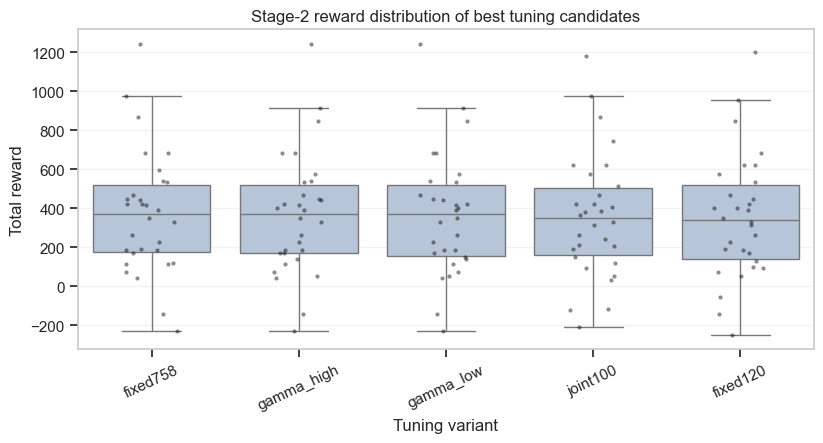

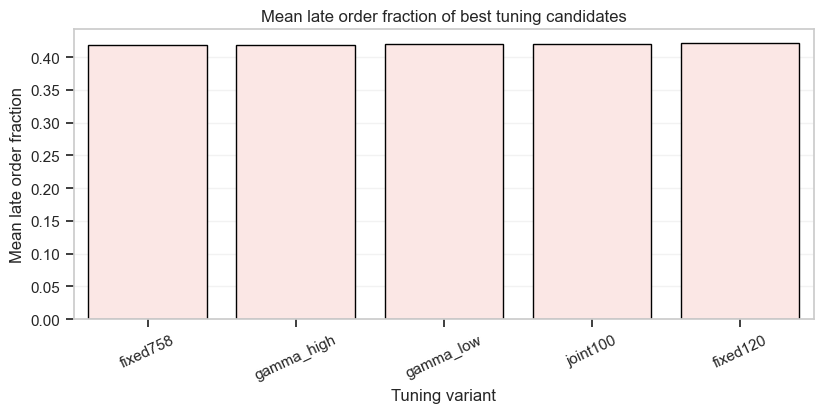

,variant,run_name,alpha,gamma,epsilon_min,risk_window,mean_total_reward,median_total_reward,mean_late_order_fraction,median_late_order_fraction,n
2,fixed758,rl_tuning_hpc_fixed758,0.008879,0.950000,0.003096,758.004,370.166667,369.0,0.418286,0.419898,30
3,gamma_high,rl_tuning_hpc_gamma_high,0.005741,0.813035,0.000500,758.004,364.166667,369.0,0.419359,0.419898,30
4,gamma_low,rl_tuning_hpc_gamma_low,0.003885,0.200000,0.044245,758.004,363.500000,369.0,0.419476,0.419898,30
0,joint100,rl_tuning_hpc_100,0.005000,0.200000,0.020000,120.000,356.833333,348.5,0.420611,0.422569,30
1,fixed120,rl_tuning_hpc_fixed120,0.016225,0.950000,0.000500,120.000,352.833333,338.5,0.421370,0.422945,30


In [25]:
# Thesis figure export: Stage-2 reward distribution across tuning variants
from pathlib import Path
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

FIGURE_DIR = Path("../../Thesis/BA/figures/rl_results")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TUNING_ROOT = Path("results/rl_tuning_results")
selected_runs = [
    ("rl_tuning_hpc_100", "joint100"),
    ("rl_tuning_hpc_fixed120", "fixed120"),
    ("rl_tuning_hpc_fixed758", "fixed758"),
    ("rl_tuning_hpc_gamma_high", "gamma_high"),
    ("rl_tuning_hpc_gamma_low", "gamma_low"),
]

evaluation_frames = []
summary_rows = []
for run_name, label in selected_runs:
    run_dir = TUNING_ROOT / run_name
    with (run_dir / "stage2" / "stage2_best_candidate.json").open("r", encoding="utf-8") as handle:
        best = json.load(handle)["best_candidate"]
    candidate_dir = run_dir / "stage2" / f"candidate_rank_{int(best['candidate_rank']):02d}_trial_{int(best['source_trial_index']):03d}"
    evaluation = pd.read_csv(candidate_dir / "evaluation.csv")
    evaluation["variant"] = label
    evaluation["run_name"] = run_name
    evaluation_frames.append(evaluation)
    summary_rows.append({
        "variant": label,
        "run_name": run_name,
        "alpha": best.get("alpha"),
        "gamma": best.get("gamma"),
        "epsilon_min": best.get("epsilon_min", best.get("target_final_epsilon")),
        "risk_window": best.get("risk_window"),
        "mean_total_reward": evaluation["total_reward"].mean(),
        "median_total_reward": evaluation["total_reward"].median(),
        "mean_late_order_fraction": evaluation["late_order_fraction"].mean(),
        "median_late_order_fraction": evaluation["late_order_fraction"].median(),
        "n": len(evaluation),
    })

evaluations = pd.concat(evaluation_frames, ignore_index=True)
summary = pd.DataFrame(summary_rows).sort_values("mean_total_reward", ascending=False)
order = summary["variant"].tolist()

fig, ax = plt.subplots(figsize=(8.4, 4.6))
sns.boxplot(
    data=evaluations,
    x="variant",
    y="total_reward",
    order=order,
    ax=ax,
    color="lightsteelblue",
    showfliers=False,
)
sns.stripplot(
    data=evaluations,
    x="variant",
    y="total_reward",
    order=order,
    ax=ax,
    color="black",
    alpha=0.45,
    size=3,
    jitter=0.18,
)
ax.set_title("Stage-2 reward distribution of best tuning candidates")
ax.set_xlabel("Tuning variant")
ax.set_ylabel("Total reward")
ax.tick_params(axis="x", rotation=25)
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
for ext in ["pdf", "png"]:
    fig.savefig(FIGURE_DIR / f"rl_tuning_variant_reward_distribution.{ext}", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8.4, 4.3))
sns.barplot(
    data=summary,
    x="variant",
    y="mean_late_order_fraction",
    order=order,
    ax=ax,
    color="mistyrose",
    edgecolor="black",
)
ax.set_title("Mean late order fraction of best tuning candidates")
ax.set_xlabel("Tuning variant")
ax.set_ylabel("Mean late order fraction")
ax.tick_params(axis="x", rotation=25)
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
for ext in ["pdf", "png"]:
    fig.savefig(FIGURE_DIR / f"rl_tuning_variant_late_fraction.{ext}", dpi=300, bbox_inches="tight")
plt.show()

display(summary)